In [26]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact
import info
import loader
import stats
import plotter

dataset_path = "../dataset/processed/features.csv"
    
try:
  df = loader.load_data(dataset_path)
except FileNotFoundError as e:
  print(f"Error: dataset file ({dataset_path}) not found")
  sys.exit(1)

### Contare il numero di famiglie linguistiche, sottofamiglie, genus e lingue all'interno del dataset
Segue una visualizzazione della varietà del dataset.
La categoria tassonomica di sub-family viene utilizzata poco nel dataset, in quanto è difficile far conformare a questo schema rigido formato da 3 categorie i diversi alberi genealogici delle lingue.

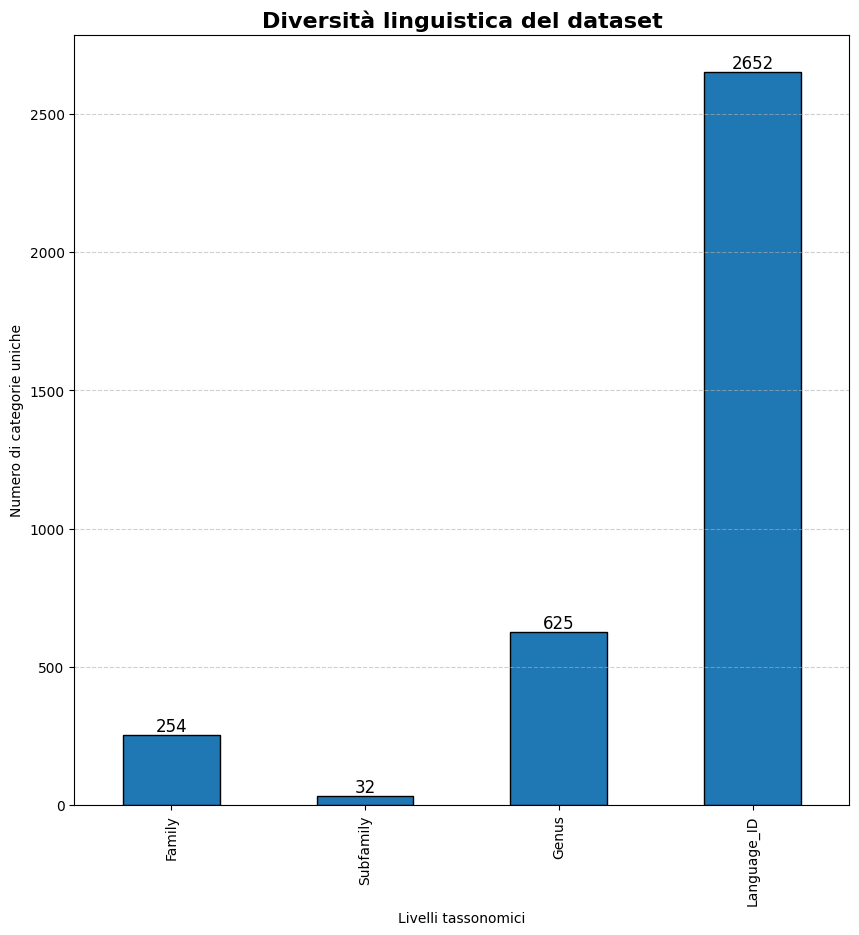

In [27]:
categories_count = df[["Family", "Subfamily", "Genus", "Language_ID"]].nunique()
categories_count
plotter.bar_plot(
  categories_count, 
  title="Diversità linguistica del dataset",
  xlabel="Livelli tassonomici",
  ylabel="Numero di categorie uniche",
  annotate=True
)

### Contare il numero di lingue per ciascuna macroarea nel dataset
Certe aree del mondo sono meno linguisticamente varie rispetto ad altre: i motivi sono molteplici e spaziano da motivi geografici, storici, politici e culturali.

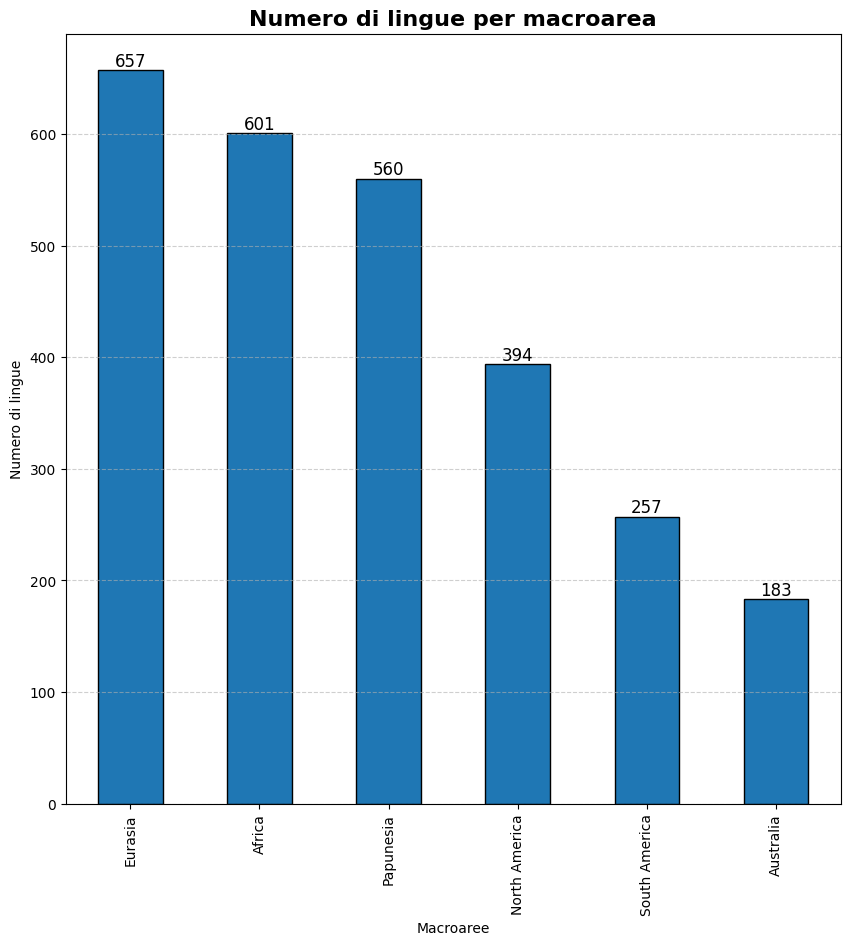

In [28]:
qdf = stats.count(df, "Language_ID", "Macroarea", sort=True)

plotter.bar_plot(
  qdf,
  title="Numero di lingue per macroarea",
  xlabel="Macroaree",
  ylabel="Numero di lingue",
  annotate=True
)

### Contare il numero di lingue per ciascun paese nel dataset
Lo stesso discorso si applica per i Paesi.

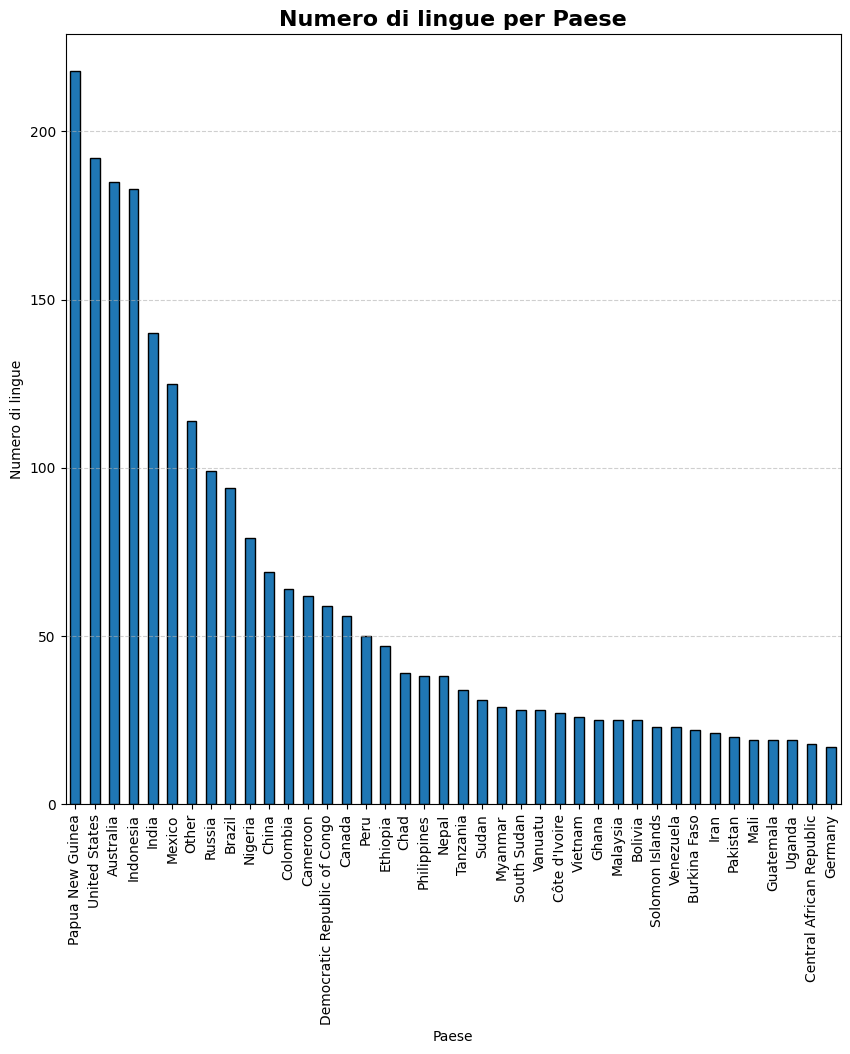

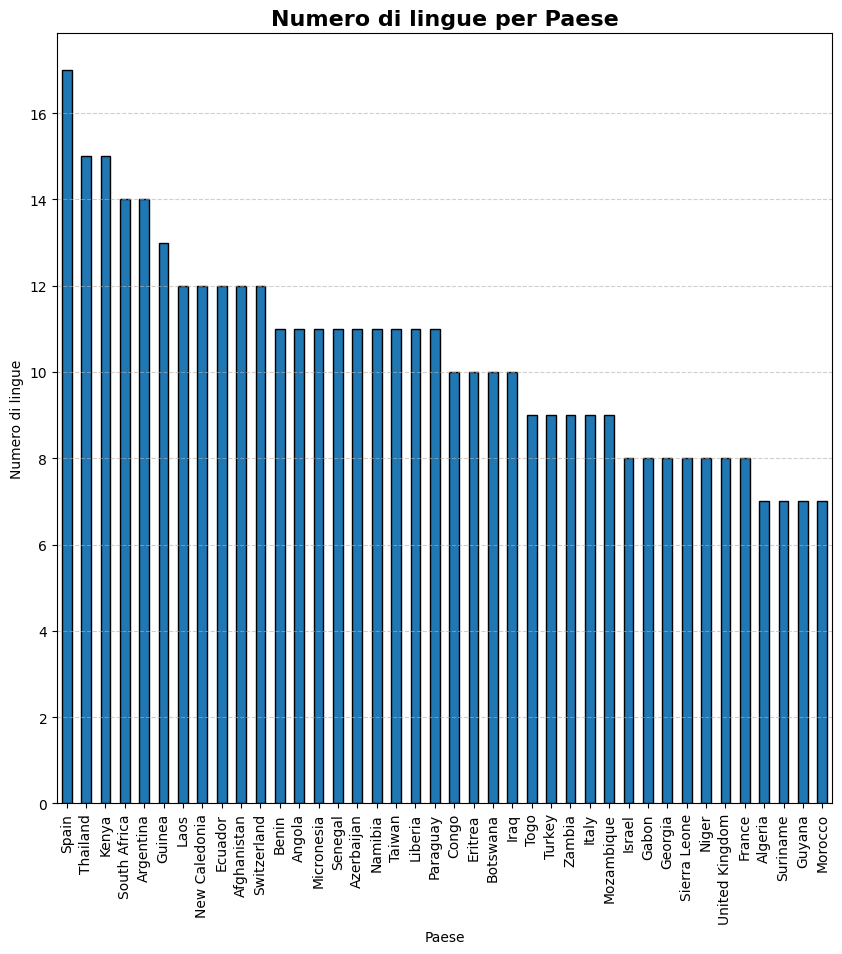

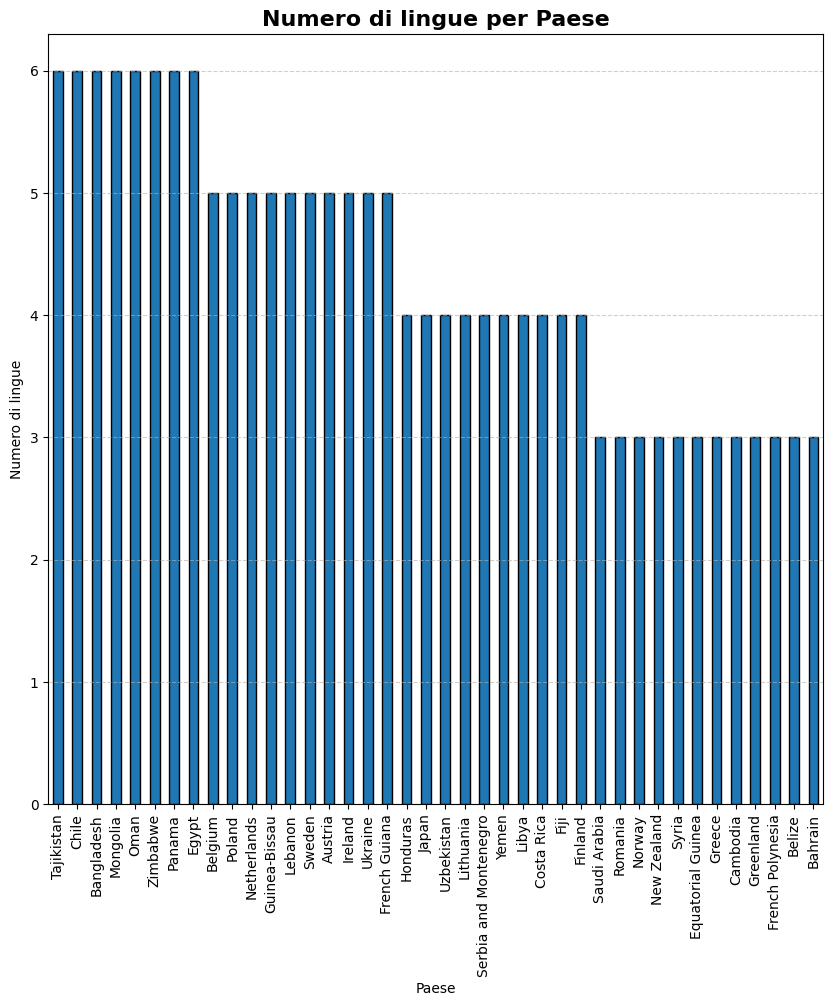

In [29]:
qdf = stats.count(df, "Language_ID", "Country_Name", sort=True)

n_top = 120
languages_by_family = stats.pack_from(qdf, n_top).sort_values(ascending=False)
languages_by_family_chunks = stats.get_chunks(languages_by_family, n_top // 3)

for chunk in languages_by_family_chunks:
  plotter.bar_plot(
    chunk,
    title="Numero di lingue per Paese",
    xlabel="Paese",
    ylabel="Numero di lingue",
    annotate=False
  )


### Contare il numero di lingue per ciascuna famiglia linguistica nel dataset
Ovviamente esistono famiglie linguistiche più numerose di altre.

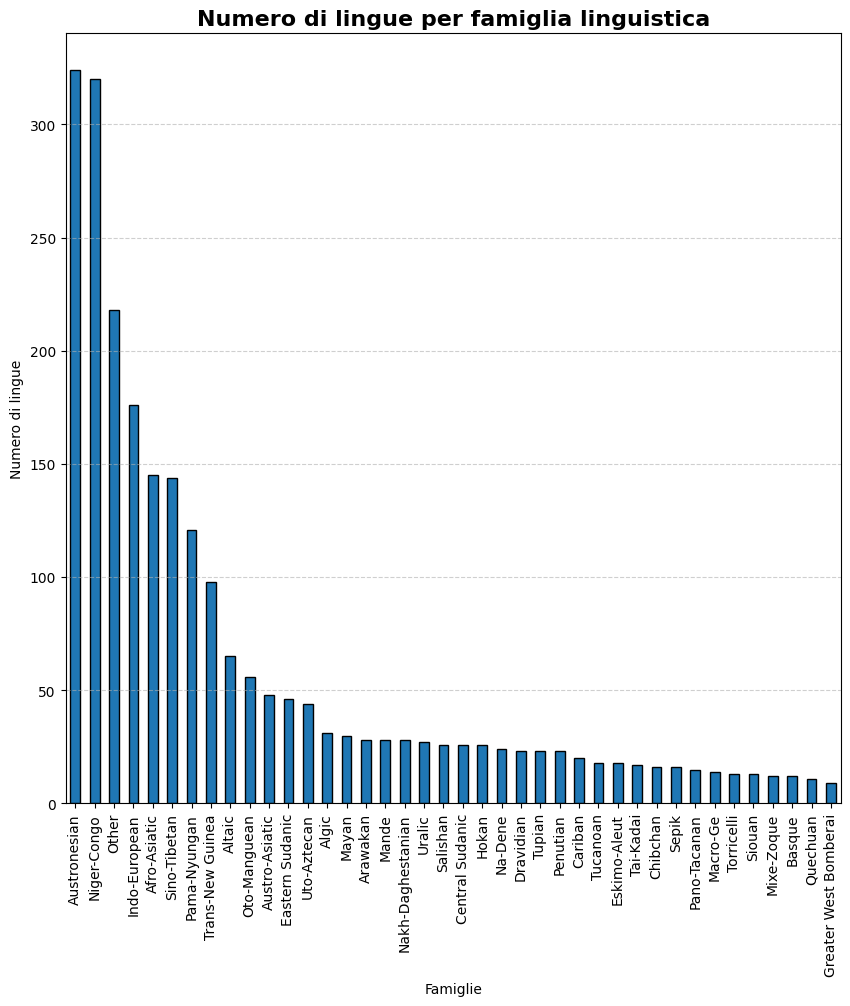

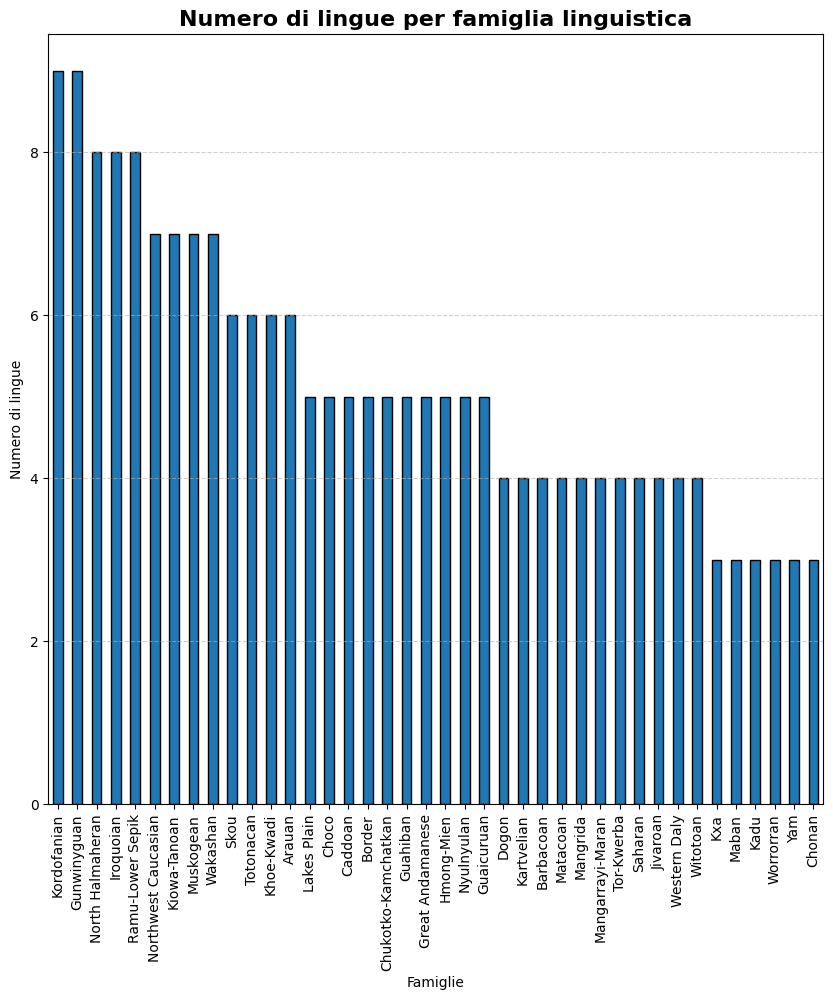

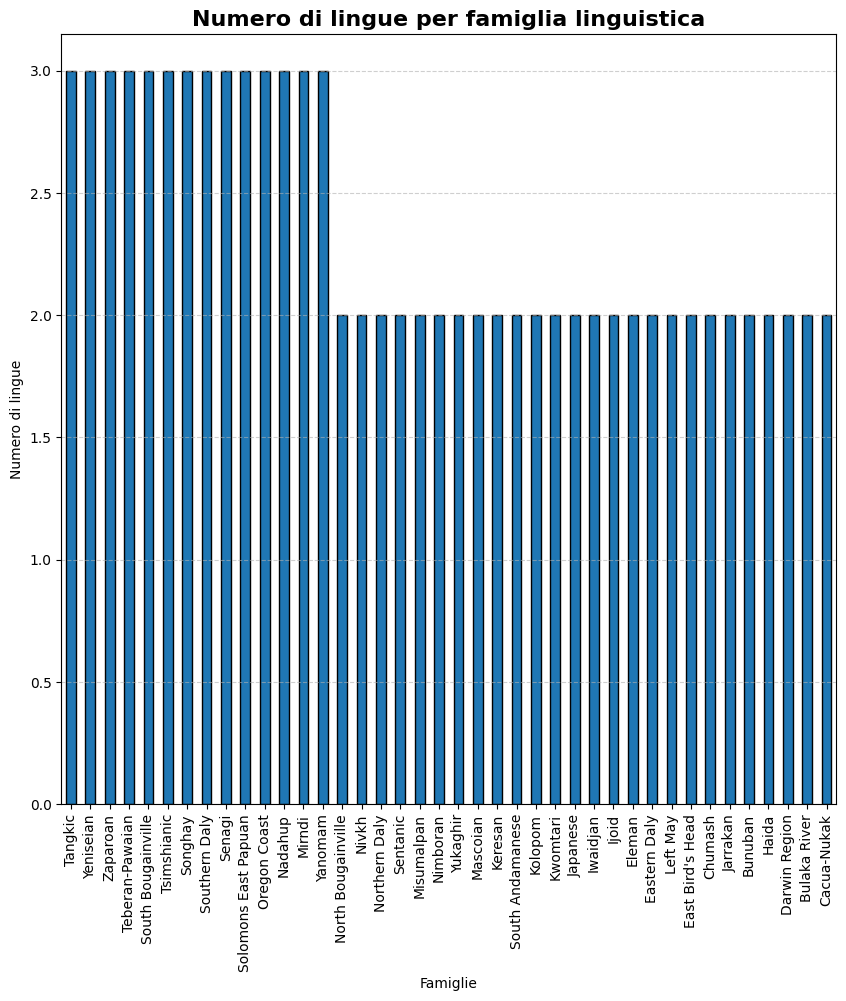

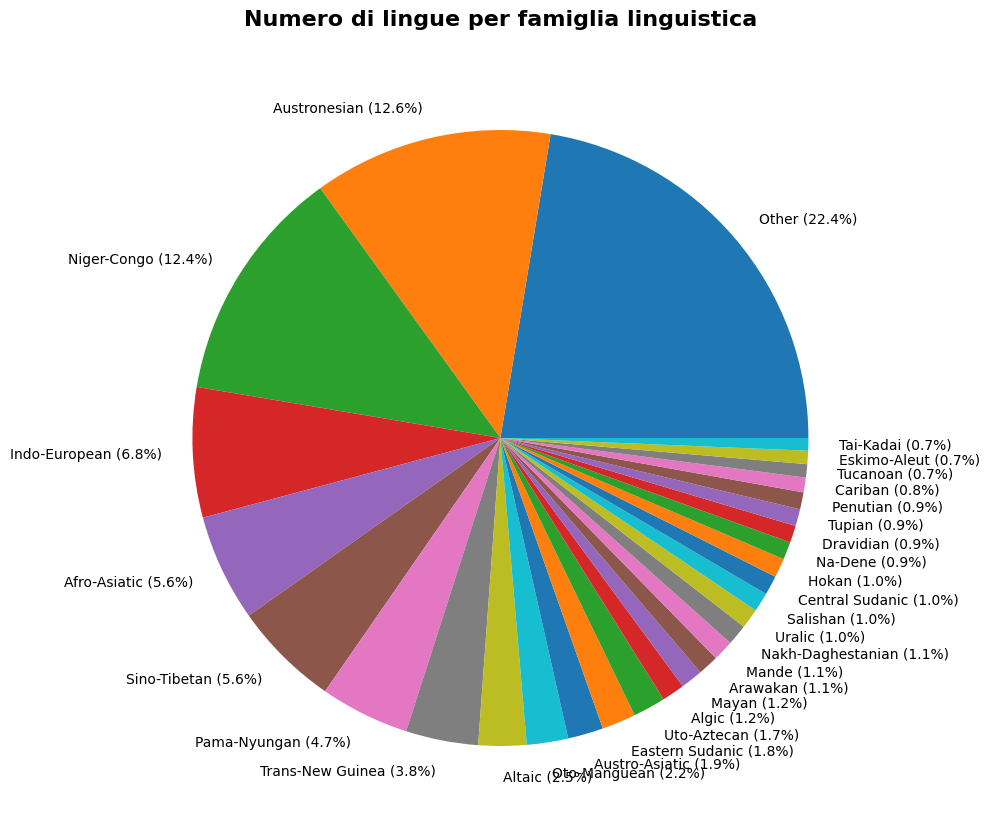

In [30]:
n_top= 120
qdf = stats.count(df, "Language_ID", "Family", sort=True)

# Questo perché era già presente un campo other nel dataset
previous_other_count = qdf.loc["other"]
qdf = qdf.drop(index="other")

languages_by_family = stats.pack_from(qdf, n_top)
languages_by_family.at["Other"] += previous_other_count

# Una volta sommato il valore precedente di other bisogna riordinare
languages_by_family = languages_by_family.sort_values(ascending=False)

languages_by_family_chunks = stats.get_chunks(languages_by_family, n_top // 3)

for chunk in languages_by_family_chunks:
  plotter.bar_plot(
    chunk,
    title="Numero di lingue per famiglia linguistica",
    xlabel="Famiglie",
    ylabel="Numero di lingue",
    annotate=False
)

n_top = 30
languages_by_family = stats.pack_from(qdf, n_top).sort_values(ascending=False)

plotter.pie_plot(
    languages_by_family,
    figsize=(10, 10),
    title="Numero di lingue per famiglia linguistica"
)

### Conteggio di famiglie per macroarea
La stessa analisi geografica può essere fatta a livello di famiglie linguistiche, un maggiore numero di famiglie linguistiche all'interno della stessa macroarea o dello stesso paese indica una maggiore divesità linguistica rispetto al mero numero di lingue diverse.

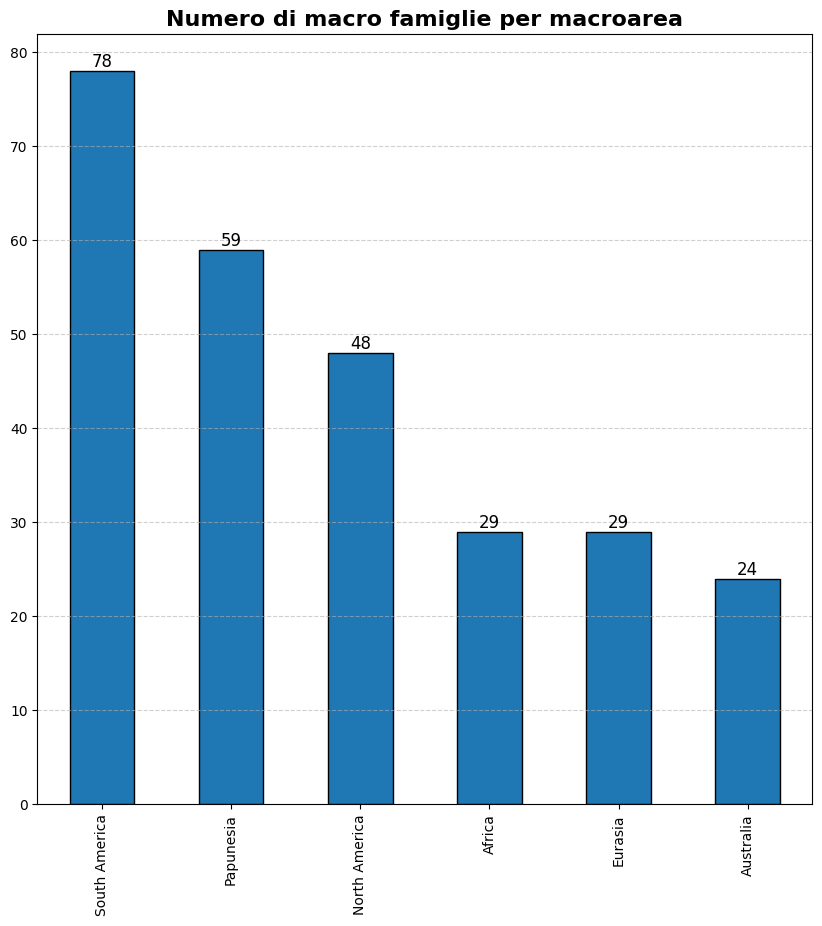

In [31]:
qdf = stats.count(df, "Family", "Macroarea", sort=True)

plotter.bar_plot(
  qdf,
  title="Numero di macro famiglie per macroarea",
  annotate=True
)

### Conteggio di famiglie per Paese
La stessa analisi geografica può essere fatta a livello di famiglie linguistiche, un maggiore numero di famiglie linguistiche all'interno della stessa macroarea o dello stesso paese indica una maggiore divesità linguistica rispetto al mero numero di lingue diverse.

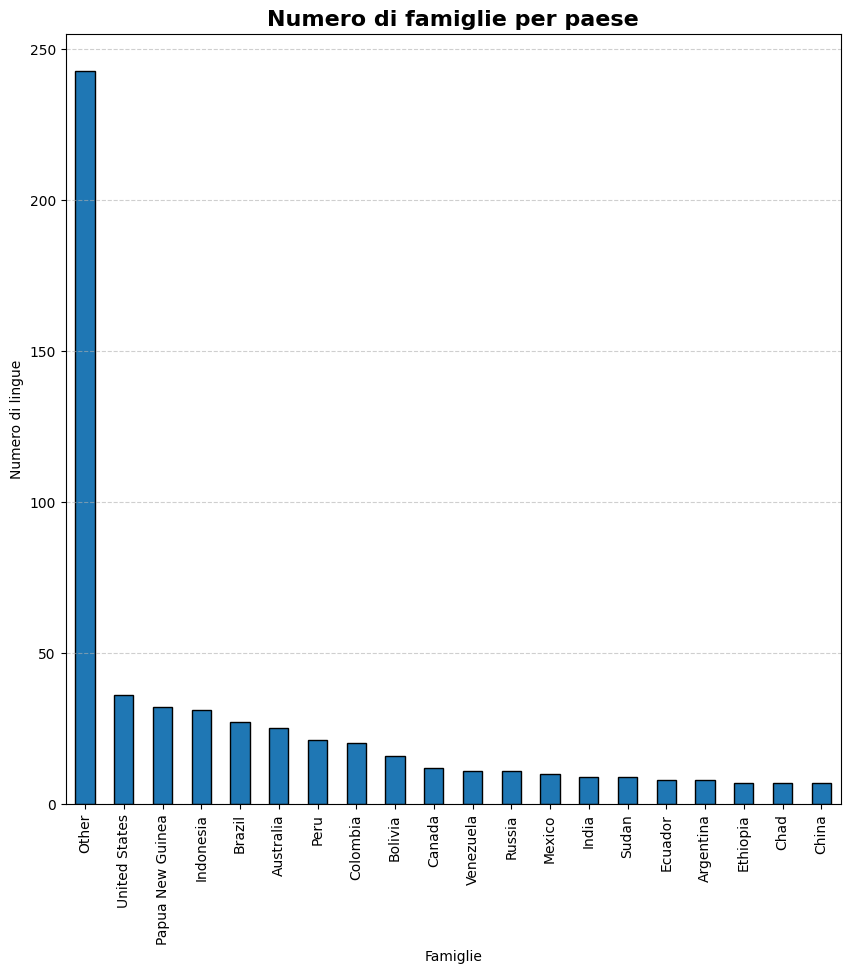

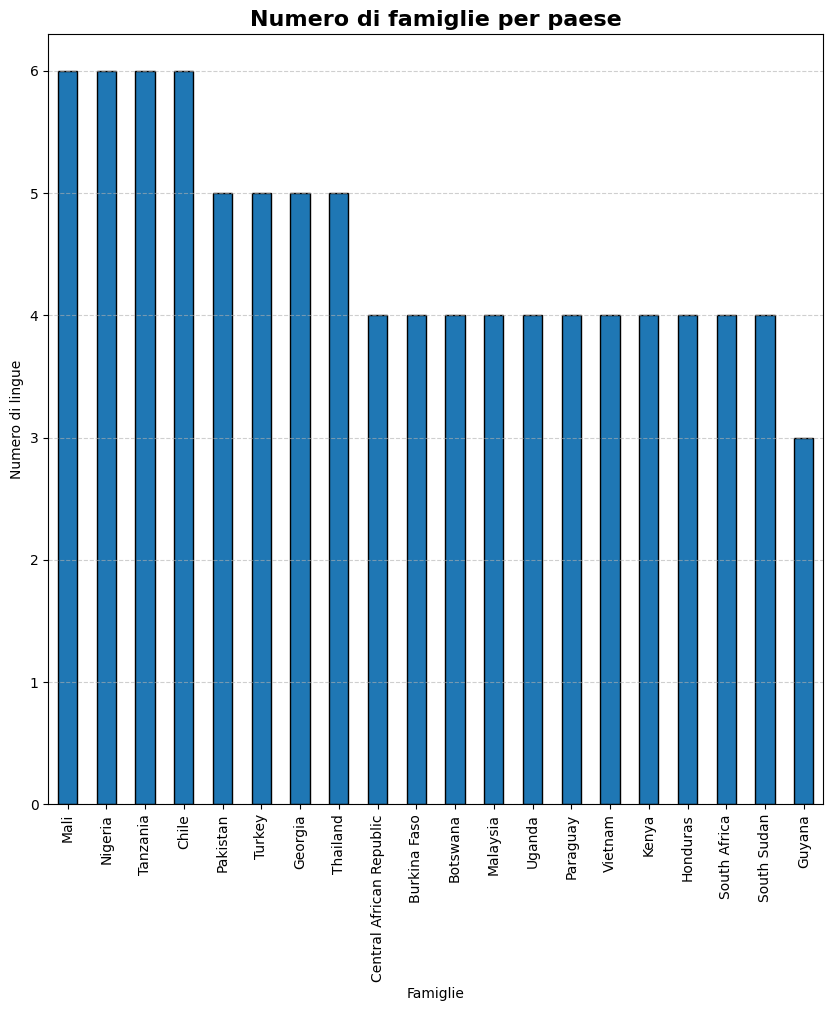

In [32]:
n_top = 40
qdf = stats.count(df, "Family", "Country_Name", sort=True)


languages_by_family = stats.pack_from(qdf, n_top).sort_values(ascending=False)
languages_by_family_chunks = stats.get_chunks(languages_by_family, n_top // 2)

for chunk in languages_by_family_chunks:
  plotter.bar_plot(
    chunk,
    title="Numero di famiglie per paese",
    xlabel="Famiglie",
    ylabel="Numero di lingue",
    annotate=False
)

### Conto di lingue divise in famiglie per Paese

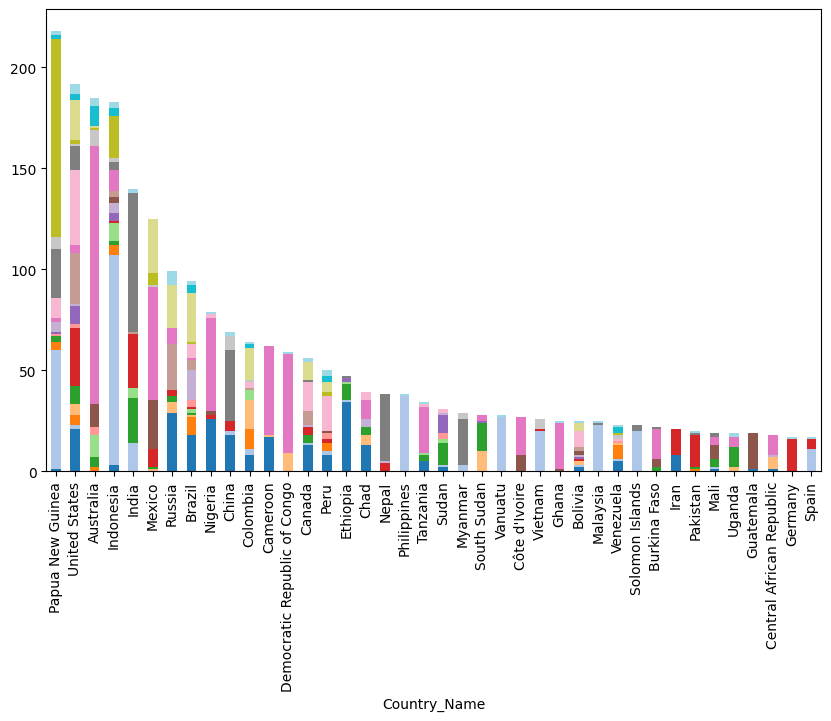

In [33]:
qdf = df.drop_duplicates(subset=["Country_Name", "Family", "Language_ID"])
qdf = pd.crosstab(qdf["Country_Name"], qdf["Family"])

qdf = qdf.assign(Total=qdf.sum(axis=1))

languages_by_family = qdf.sort_values("Total", ascending=False)
languages_by_family = languages_by_family.drop("Total", axis=1)
first_chunk = stats.get_chunks(languages_by_family, 40)[0]

plotter.stacked_bar_plot(first_chunk, legend=False)

In [40]:
def select_country(countries):
  country_name = countries
  qdf = df.copy()
  qdf = stats.filter(qdf, "Country_Name", [country_name])
  qdf = qdf.drop_duplicates(subset=["Family", "Language_ID"])
  qdf = stats.count(qdf, "Language_ID", "Family", sort=True)

  plotter.bar_plot(
    qdf,
    figsize=(10, 10),
    title=""
  )

  plotter.pie_plot(
    qdf,
    figsize=(10, 10),
    title="Numero di lingue per famiglia all'interno di un Paese"
  )

interact(select_country, countries=sorted(df["Country_Name"].unique().tolist()));

interactive(children=(Dropdown(description='countries', options=('Afghanistan', 'Albania', 'Algeria', 'America…

### Disposizione dei paesi in base alla diversità delle famiglie e diversità di lingue

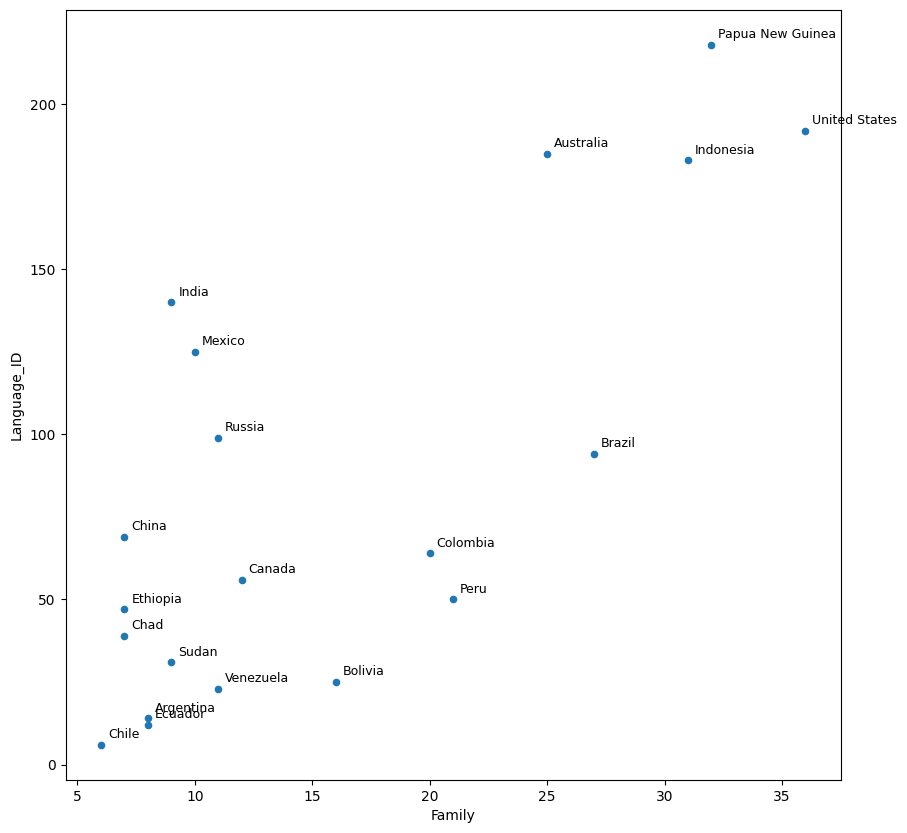

In [42]:
qdf = df.copy()
qdf = qdf.groupby("Country_Name")[["Family", "Language_ID"]].nunique().sort_values(by="Family", ascending=False).head(20)

plotter.scatter_plot(qdf, figsize=(10, 10), x="Family", y="Language_ID", annotate=True)